In [1]:
# import PCA from sklearn
import torch
import numpy as np
import matplotlib.pyplot as plt

In [2]:
w_data_file = np.load('data/NS-Re100_T1.npy')
w_data = w_data_file[:, 0, :, :].reshape(-1, 4096)
print(np.isnan(w_data).any())

False


/tmp/ipykernel_15252/613308736.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  w_data = torch.tensor(w_data).float()


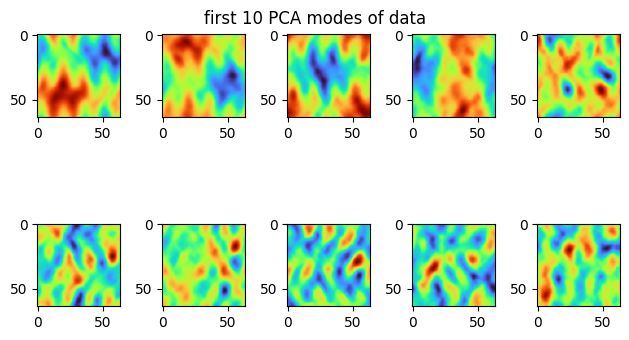

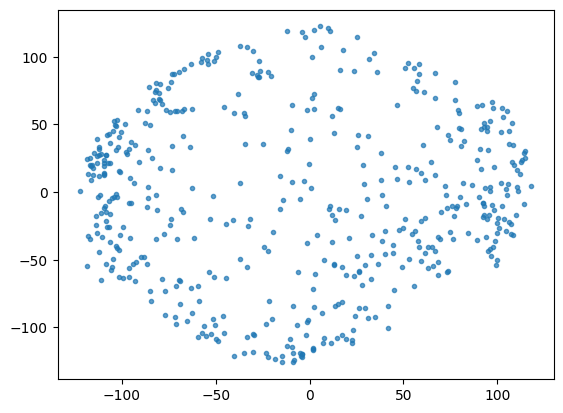

In [ ]:
w_data = torch.tensor(w_data).float()

U,S,V = torch.svd(w_data-torch.mean(w_data,0))

fig,axs = plt.subplots(2,5) 
for i in range(axs.shape[0]):
    for j in range(axs.shape[1]):
        axs[i][j].imshow(V[:,i*axs.shape[1]+j].reshape(64,64).cpu().numpy(), cmap=plt.colormaps['turbo'])

fig.suptitle('first 10 PCA modes of data',y=0.8)
fig.tight_layout()
plt.show()
# plt.savefig(f'data/{folder}/PCA_data.png')

plt.figure()
mode1 = V[:,0]
mode2 = V[:,1]

x = torch.einsum('bi,i ->b',w_data,mode1).cpu()
y = torch.einsum('bi,i ->b',w_data,mode2).cpu()

plt.plot(x,y,'.',label='data',alpha=0.7)
plt.show()
# plt.savefig(f'data/{folder}/2PCA_modes.png')

In [5]:
from sklearn.decomposition import PCA

flat_data = w_data.detach().cpu().numpy()
print(f"Reshaped data for PCA with shape: {flat_data.shape}")

# Initialize and fit the PCA model
pca = PCA(n_components=10)
principal_components = pca.fit_transform(flat_data)

print("PCA fitting complete.")

Reshaped data for PCA with shape: (500, 4096)
PCA fitting complete.


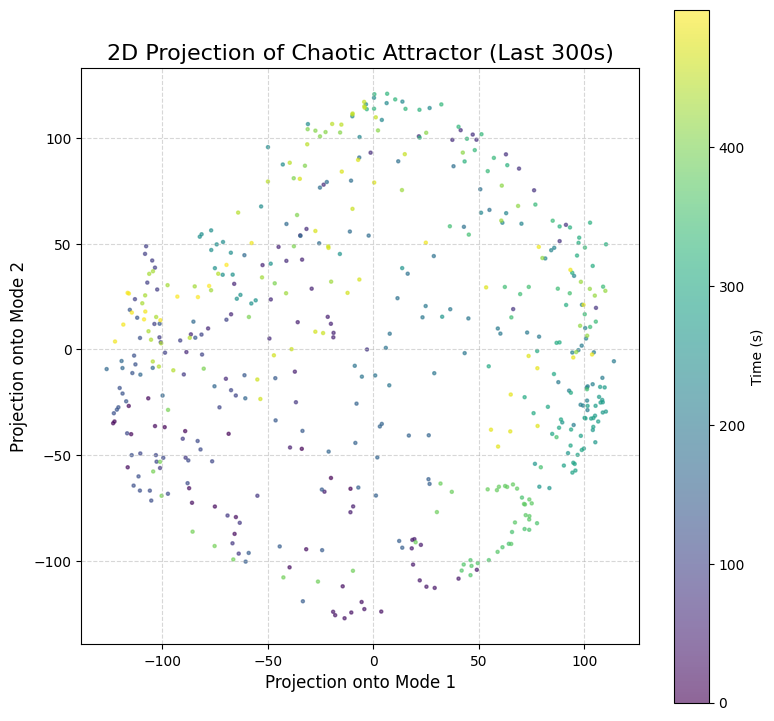

In [6]:
plt.figure(figsize=(9, 9))
    
# We can color the points by time to see the evolution, using a subset for clarity
# num_points_to_plot = 5000 # Plot a subset to avoid a dense blob
# subset_indices = np.linspace(0, len(principal_components) - 1, num_points_to_plot, dtype=int)
time_subset = np.arange(len(principal_components))

sc = plt.scatter(
	principal_components[:, 0],
	principal_components[:, 1],
	c=time_subset,
	cmap='viridis',
	s=5,
	alpha=0.6
)

plt.colorbar(sc, label='Time (s)')
plt.xlabel("Projection onto Mode 1", fontsize=12)
plt.ylabel("Projection onto Mode 2", fontsize=12)
plt.title("2D Projection of Chaotic Attractor (Last 300s)", fontsize=16)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()